### Mitigrating Cascading Failures in Cloud Infrastructures

The main objective is to create a system that can detect failure from a pre-failure state. The dataset is from a github repository maintained by NetManAIOps. There are 3 files, the train, test, and test_label. The training data is what normal operating data looks like. The test data contains real world data which includes actual system failures. The test_label is a binary file that indicate which test case is a failure. 

### Step 0: Import dataset and install essential libraries to the environment

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import accuracy_score, recall_score, precision_score, classification_report
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint

### Step 1: Data Ingestion and Preperation

In [2]:
train_path  = 'machine-1-1_train.txt'
test_path = 'machine-1-1_test.txt' 
label_path = 'machine-1-1_label.txt'

# Load datasets
train_df = pd.read_csv(train_path, header=None)
test_df = pd.read_csv(test_path, header=None)
label_df = pd.read_csv(label_path, header=None)

num_features = train_df.shape[1]
feature_cols = [f"metric_{i}" for i in range(num_features)]

train_df.columns = feature_cols
test_df.columns = feature_cols



# Display basic information about the datasets
# print("Training Data Shape:", train_df.shape)   

test_df["is_anomaly"] = label_df.iloc[:, 0]

### Step 2: Exploratory Analysis

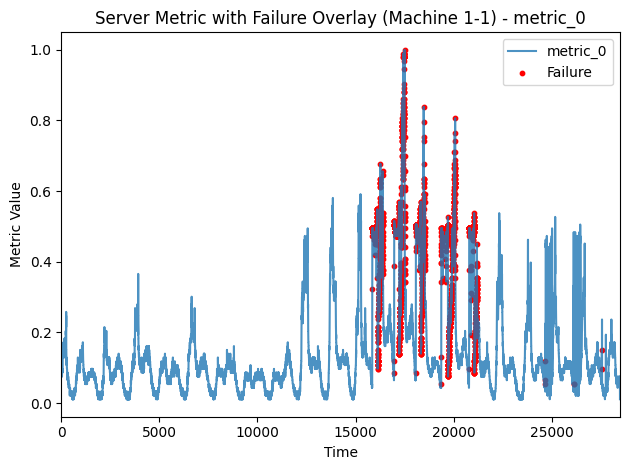

In [64]:
# Display the graph
# for i in range(num_features):
#     plt.figure(figsize=(14, 5))
#     plt.plot(test_df.index, test_df[f"metric_{i}"], label=f"metric_{i}", alpha=0.8)
#     # Highlight anomaly regions
#     anomalies = test_df[test_df["is_anomaly"] == 1]
#     plt.scatter(
#         anomalies.index,
#         anomalies[f"metric_{i}"],
#         color="red",
#         label="Failure",
#         s=10
#     )
#     plt.title(f"Server Metric with Failure Overlay (Machine 1-1) - metric_{i}")
#     plt.xlim(0, train_df.shape[0]) # Set x-axis limits to the range of our data
#     plt.xlabel("Time")
#     plt.ylabel("Metric Value")
#     plt.legend()
#     plt.tight_layout()
# plt.figure(figsize=(14, 5))

plt.plot(test_df.index, test_df[f"metric_0"], label=f"metric_0", alpha=0.8)
# Highlight anomaly regions
anomalies = test_df[test_df["is_anomaly"] == 1]
plt.scatter(
    anomalies.index,
    anomalies[f"metric_0"],
    color="red",
    label="Failure",
    s=10
)
plt.title(f"Server Metric with Failure Overlay (Machine 1-1) - metric_0")
plt.xlim(0, train_df.shape[0]) # Set x-axis limits to the range of our data
plt.xlabel("Time")
plt.ylabel("Metric Value")
plt.legend()
plt.tight_layout()

## Heatmap to determine relationship between variables

In [54]:
# corr_matrix = test_df.corr().sort_values(by="is_anomaly", ascending = False)

# corr_matrix

### Step 3: Feature Engineering 

In [11]:
def create_time_features(df, metrics, window=10, lag=100):
    df_feat = pd.DataFrame()

    for col in metrics:
        df_feat[f"{col}_roll_mean"] = df[col].rolling(window,center = True).mean()
        df_feat[f"{col}_roll_std"] = df[col].rolling(window, center = True).std()
        df_feat[f"{col}_lag_{lag}"] = df[col].shift(-lag)
    
    df_feat["is_anomaly"] = df["is_anomaly"]

    return df_feat

In [80]:
selected_metrics = ["metric_0","metric_12","metric_13"]

# Split the sequential test data before creating rolling-window features to avoid leakage
df_seq_train, df_seq_test = train_test_split(test_df, test_size=0.3, shuffle=False)

# Create time-based features independently on the train and test segments
train_feat = create_time_features(df_seq_train, selected_metrics)
test_feat = create_time_features(df_seq_test, selected_metrics)

# Drop rows with NaNs introduced by rolling/lag operations and reset indices
train_feat = train_feat.dropna()
test_feat = test_feat.dropna()

# Prepare feature / label splits for modeling
X_train = train_feat.drop(columns=["is_anomaly"])
y_train = train_feat["is_anomaly"]
X_test = test_feat.drop(columns=["is_anomaly"])
y_test = test_feat["is_anomaly"]


### Step 4: Model Training

In [98]:
model = xgb.XGBClassifier(objective='binary:logistic', n_estimators=100, eval_metric='logloss')

model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


## Parameter Tuning

In [99]:
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": randint(50,200),
    "max_depth" : randint(2,20),
    "min_child_weight" : randint(1,10),
}

random_search = RandomizedSearchCV(
    estimator=model,   
    param_distributions=param_dist,
    cv=5,
    scoring="precision" 
)

random_search.fit(X_train, y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'max_depth': <scipy.stats....001BD292710F0>, 'min_child_weight': <scipy.stats....001BD17F35870>, 'n_estimators': <scipy.stats....001BD291CD960>}"
,n_iter,10
,scoring,'precision'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


### Step 5: Evaluation

In [100]:
y_pred = random_search.predict(X_test)

y_pred_proba = random_search.predict_proba(X_test)

In [101]:
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score

recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)

print(f"Recall:    {recall:.3f}")
print(f"Precision: {precision:.3f}")


Recall:    0.691
Precision: 0.499


In [102]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.977     0.950     0.964      7875
           1      0.499     0.691     0.580       564

    accuracy                          0.933      8439
   macro avg      0.738     0.821     0.772      8439
weighted avg      0.945     0.933     0.938      8439



In [103]:
# Convert to numpy for speed
y_true_array = y_test.values

# First occurrence of failure
true_failure_idx = np.where(y_true_array == 1)
predict_failure_idx = np.where(y_pred == 1)

for i in range(len(true_failure_idx[0])):
    print(f"true failures index: {true_failure_idx[0][i]} Predicted Index: {predict_failure_idx[0][i]}")


true failures index: 0 Predicted Index: 1
true failures index: 1 Predicted Index: 8
true failures index: 2 Predicted Index: 9
true failures index: 3 Predicted Index: 10
true failures index: 4 Predicted Index: 11
true failures index: 5 Predicted Index: 12
true failures index: 6 Predicted Index: 13
true failures index: 7 Predicted Index: 14
true failures index: 8 Predicted Index: 15
true failures index: 9 Predicted Index: 16
true failures index: 10 Predicted Index: 17
true failures index: 11 Predicted Index: 18
true failures index: 12 Predicted Index: 19
true failures index: 13 Predicted Index: 20
true failures index: 14 Predicted Index: 21
true failures index: 15 Predicted Index: 22
true failures index: 16 Predicted Index: 23
true failures index: 17 Predicted Index: 24
true failures index: 18 Predicted Index: 25
true failures index: 19 Predicted Index: 26
true failures index: 20 Predicted Index: 27
true failures index: 21 Predicted Index: 28
true failures index: 22 Predicted Index: 29
t

In [104]:
y_pred_array = y_pred

pred_failure_indices = np.where(y_pred_array == 1)[0]

if len(pred_failure_indices) == 0:
    print("⚠️ Model never raised an alarm.")
    lead_time = None
else:
    pred_failure_idx = pred_failure_indices[0]


In [105]:
lead_time_steps = true_failure_idx - pred_failure_idx

In [106]:
lead_time_seconds = lead_time_steps
lead_time_minutes = lead_time_seconds / 60

# for i in range(len(lead_time_seconds[0])): 
#     print(f"Lead Time: {lead_time_seconds[0][i]} seconds ({lead_time_minutes[0][i]:.2f} minutes)")


Text(0.5, 1.0, 'Rolling Window Analysis with predicted first-anomaly per 500-row block')

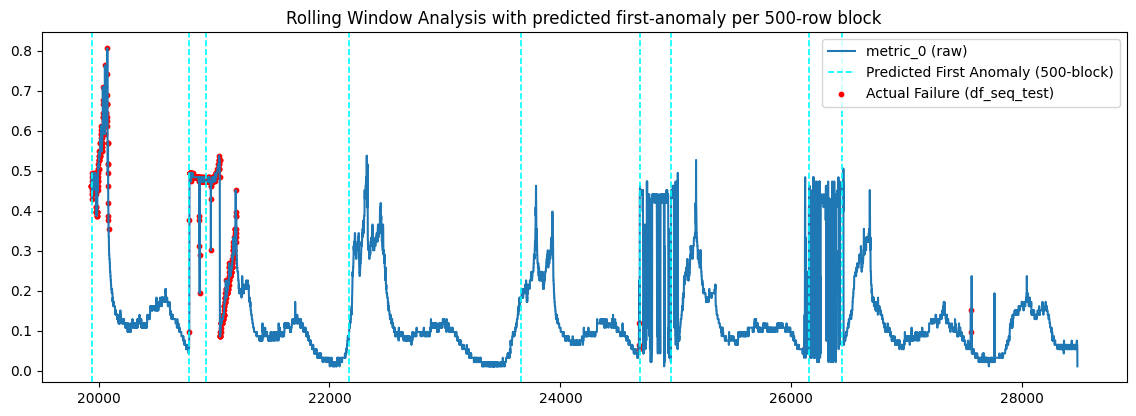

In [107]:
plt.figure(figsize=(14, 10))
# Subplot 1: raw metric_0 with anomalies from df_seq_test (if available)
plt.subplot(2, 1, 1)
try:
    plt.plot(df_seq_test.index, df_seq_test['metric_0'], label='metric_0 (raw)')
    # Compute predicted anomaly indices mapped to df_seq_test index (if predictions exist)
    try:
        y_pred_array = np.asarray(y_pred)
        pred_positions = np.where(y_pred_array == 1)[0]
        if len(pred_positions) > 0:
            pred_df_indices = X_test.index[pred_positions]
        else:
            pred_df_indices = np.array([], dtype=int)
    except Exception:
        pred_df_indices = np.array([], dtype=int)
    # Split df_seq_test into blocks of 500 (positional slices) and find the first predicted anomaly in each block
    block_size = 500
    n = len(df_seq_test)
    block_first_pred = []
    for start in range(0, n, block_size):
        block = df_seq_test.iloc[start:start+block_size]
        # find predicted df indices that fall into this block
        preds_in_block = [idx for idx in pred_df_indices if idx in block.index]
        if len(preds_in_block) > 0:
            # take the first predicted anomaly (earliest index) in this block
            block_first_pred.append(preds_in_block[0])
    # Plot vertical lines for predicted first-anomaly per 500-row block
    pred_block_label = True
    for idx in block_first_pred:
        lbl = 'Predicted First Anomaly (500-block)' if pred_block_label else None
        plt.axvline(x=idx, color='cyan', linestyle='--', linewidth=1.2, label=lbl)
        pred_block_label = False
    # Also plot actual anomaly points
    anom_seq = np.where(df_seq_test['is_anomaly'] == 1)[0]
    if len(anom_seq) > 0:
        plt.scatter(df_seq_test.index[anom_seq], df_seq_test['metric_0'].iloc[anom_seq], color='red', s=10, label='Actual Failure (df_seq_test)')
except Exception:
    plt.text(0.5, 0.5, 'df_seq_test not available', ha='center', va='center')
plt.legend()
plt.title('Rolling Window Analysis with predicted first-anomaly per 500-row block')